In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
diabetes = load_diabetes()

X = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

y = pd.Series(
    diabetes.target,
    name="disease_progression"
)

df = pd.concat([X, y], axis=1)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Information:")
df.info()

Dataset Shape: (442, 11)

Column Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'disease_progression']

Missing Values:
age                    0
sex                    0
bmi                    0
bp                     0
s1                     0
s2                     0
s3                     0
s4                     0
s5                     0
s6                     0
disease_progression    0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  442 non-null    float64
 1   sex                  442 non-null    float64
 2   bmi                  442 non-null    float64
 3   bp                   442 non-null    float64
 4   s1                   442 non-null    float64
 5   s2                   442 non-null    float64
 6   s3                   442 non-null   

In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


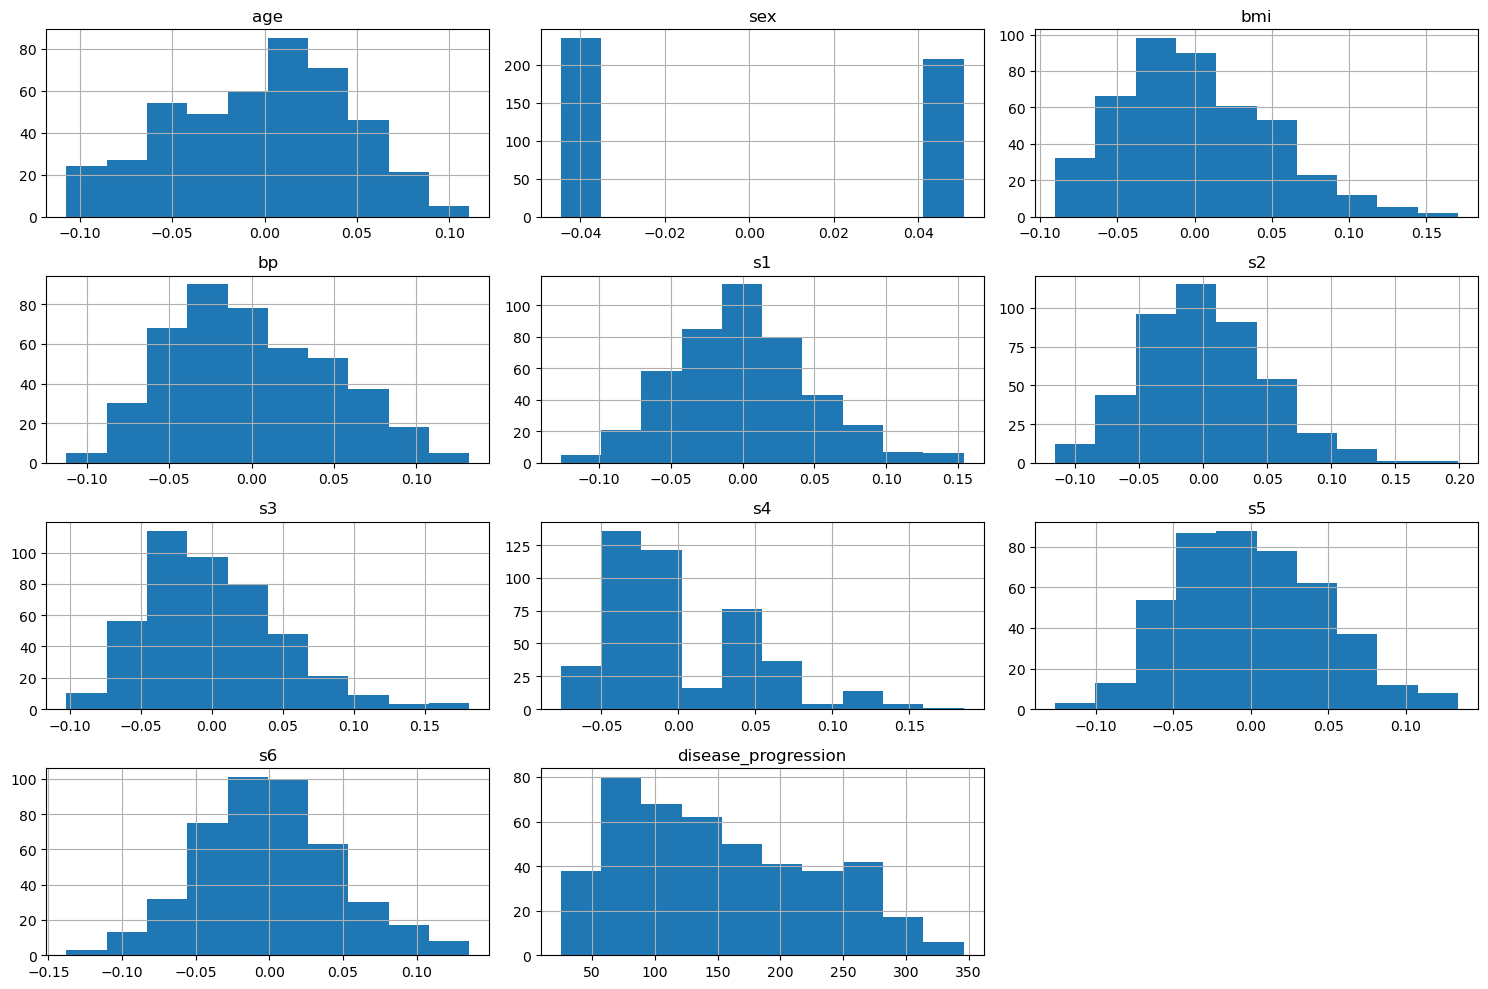

In [ ]:
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

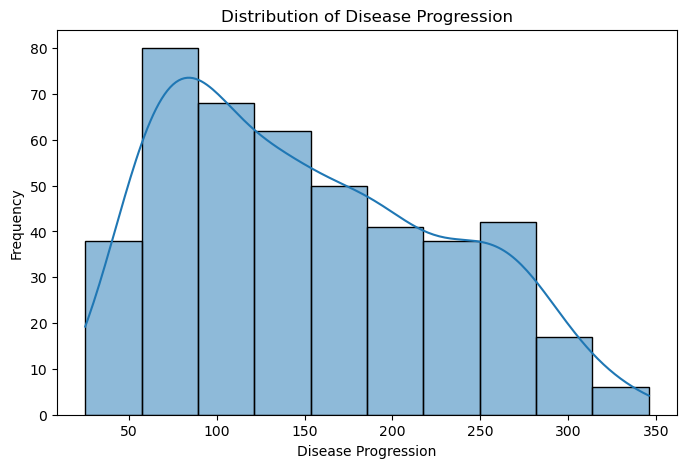

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["disease_progression"], kde=True)
plt.title("Distribution of Disease Progression")
plt.xlabel("Disease Progression")
plt.ylabel("Frequency")
plt.show()

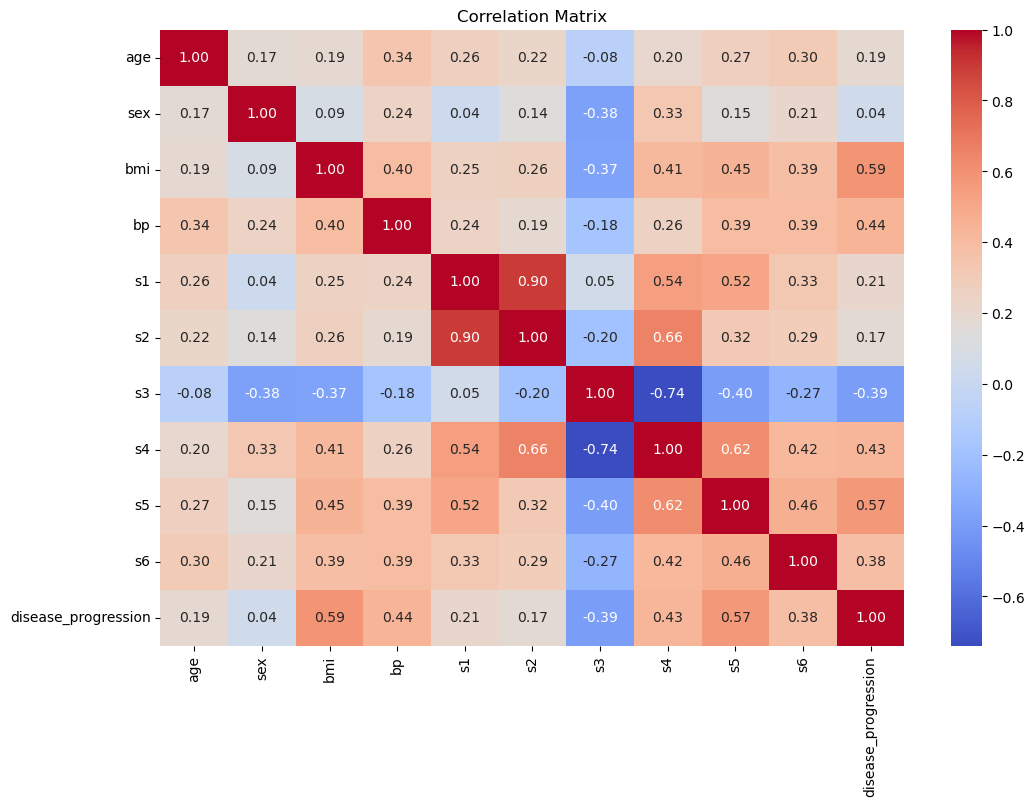

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
correlation_with_target = df.corr()["disease_progression"].sort_values(
    ascending=False
)
print(correlation_with_target)

disease_progression    1.000000
bmi                    0.586450
s5                     0.565883
bp                     0.441482
s4                     0.430453
s6                     0.382483
s1                     0.212022
age                    0.187889
s2                     0.174054
sex                    0.043062
s3                    -0.394789
Name: disease_progression, dtype: float64


In [ ]:
X = df.drop("disease_progression", axis=1)
y = df["disease_progression"]
print("Features:")
print(X.columns.tolist())
print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target:
disease_progression


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (353, 10)
Testing data: (89, 10)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred = model.predict(X_test)
print("First 10 predicted values:")
print(y_pred[:10])

First 10 predicted values:
[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Model Evaluation")
print("-----------------")
print("R² Score :", r2)
print("MAE      :", mae)
print("RMSE     :", rmse)

Model Evaluation
-----------------
R² Score : 0.4526027629719196
MAE      : 42.79409467959994
RMSE     : 53.85344583676592


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients["Absolute_Coefficient"] = abs(
    coefficients["Coefficient"]
)
coefficients = coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)
coefficients

,Feature,Coefficient,Absolute_Coefficient
4,s1,-931.488846,931.488846
8,s5,736.198859,736.198859
2,bmi,542.428759,542.428759
5,s2,518.062277,518.062277
3,bp,347.703844,347.703844
7,s4,275.317902,275.317902
1,sex,-241.964362,241.964362
6,s3,163.419983,163.419983
9,s6,48.670657,48.670657
0,age,37.904021,37.904021


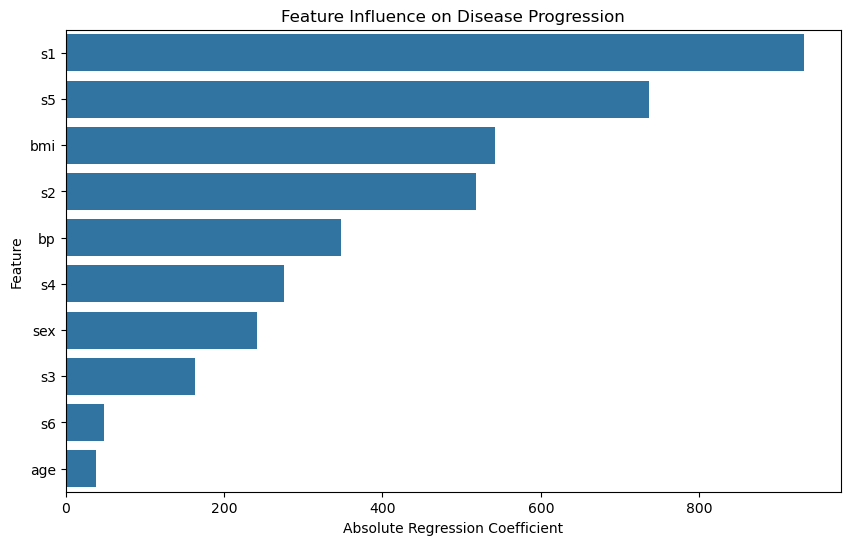

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coefficients,
    x="Absolute_Coefficient",
    y="Feature"
)
plt.title("Feature Influence on Disease Progression")
plt.xlabel("Absolute Regression Coefficient")
plt.ylabel("Feature")
plt.show()

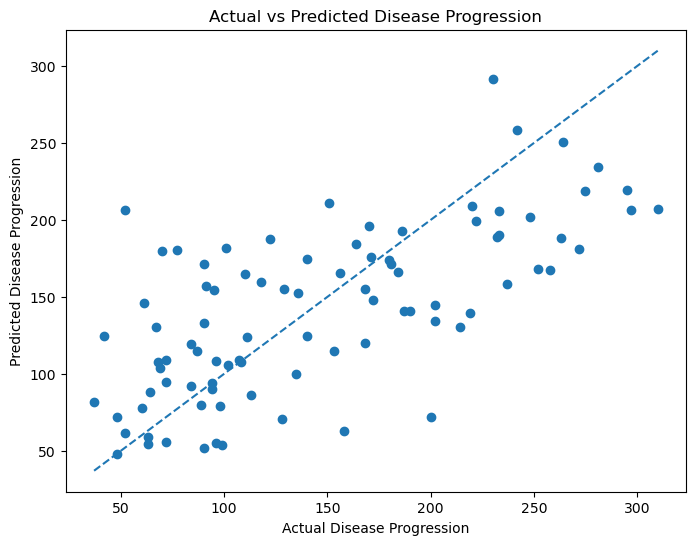

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.xlabel("Actual Disease Progression")
plt.ylabel("Predicted Disease Progression")
plt.title("Actual vs Predicted Disease Progression")
plt.show()

In [ ]:
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("\nFeature Influence:")
print(coefficients[["Feature", "Coefficient"]])

R² Score: 0.4526027629719196
MAE: 42.79409467959994
RMSE: 53.85344583676592

Feature Influence:
  Feature  Coefficient
4      s1  -931.488846
8      s5   736.198859
2     bmi   542.428759
5      s2   518.062277
3      bp   347.703844
7      s4   275.317902
1     sex  -241.964362
6      s3   163.419983
9      s6    48.670657
0     age    37.904021


# Results and Conclusion

## Model Performance
The Linear Regression model was evaluated using three metrics:
- **R² Score:** 0.4526
- **MAE:** 42.79
- **RMSE:** 53.85
The R² score of 0.4526 indicates that the model explains approximately 45.3% of the variation in disease progression in the test dataset. The MAE of 42.79 indicates the average absolute prediction error, while the RMSE of 53.85 gives greater weight to larger prediction errors.

## Feature Influence
The regression coefficients were analyzed to identify the most influential features. Based on the absolute coefficient values, the three strongest features were:
1. **s1** — coefficient: -931.49
2. **s5** — coefficient: 736.20
3. **bmi** — coefficient: 542.43
The negative coefficient for s1 indicates a negative relationship with the predicted disease progression when the other features are held constant. The positive coefficients for s5 and bmi indicate positive relationships with the prediction.

## Final Conclusion
A Linear Regression model was successfully developed to predict diabetes disease progression using 10 input features from the diabetes dataset. Exploratory Data Analysis, correlation analysis, model evaluation, feature influence analysis, and an Actual vs Predicted visualization were performed.

The model achieved an R² score of 0.4526, with an MAE of 42.79 and RMSE of 53.85. The results show that Linear Regression provides a useful baseline model for predicting disease progression, although a substantial amount of variation remains unexplained.